# Sentiment: Baseline vs Fine-Tuned Transformer

Goal: compare a classic TF-IDF + Logistic Regression baseline against a fine-tuned DistilBERT model on the same movie review sentiment data, and understand *why* one beats the other on specific examples.

## Step 1 — Load the data

Before any modeling, we need text paired with a label (positive/negative). We'll use a small subset of IMDB reviews so things run fast while we're still learning the pipeline.

In [1]:
import os
os.environ["USE_TF"] = "0"  # this machine has TensorFlow/Keras installed but we only use PyTorch; this avoids a transformers/Keras version conflict later

from datasets import load_dataset

# Load the full IMDB dataset (50k train / 50k test, balanced pos/neg)
imdb = load_dataset("imdb")

# Take a small, class-balanced subset so training/experiments are fast
train_small = imdb["train"].shuffle(seed=42).select(range(2000))
test_small = imdb["test"].shuffle(seed=42).select(range(500))

train_small, test_small

(Dataset({
     features: ['text', 'label'],
     num_rows: 2000
 }),
 Dataset({
     features: ['text', 'label'],
     num_rows: 500
 }))

In [2]:
print(train_small[0])

{'text': 'There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier\'s plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities... The main character is weak and weirdo, but have "clairvoyance". People like to compare, to judge, to evaluate. How about just enjoying? Funny thing too, people writing Fortier looks American but, on the other hand, arguing they prefer American series (!!!). Maybe it\'s the language, or the spirit, but I think this series is more English than American. By the way, the actors are really good and funny. The acting is not superficial at all...', 'label': 1}


## Step 2 — Look at the data before modeling

Two quick sanity checks: are positive/negative roughly balanced in our subset, and how long are these reviews? Both affect how we approach modeling later.

In [3]:
import pandas as pd

# Convert to a DataFrame just because it's easier to inspect/count with pandas
train_df = train_small.to_pandas()

# Count how many of each label we have (0 = negative, 1 = positive)
print("Class counts:\n", train_df["label"].value_counts())

# Review length in words, so we know roughly how long the text inputs are
train_df["num_words"] = train_df["text"].str.split().str.len()
print("\nReview length (words) stats:\n", train_df["num_words"].describe())

Class counts:
 label
1    1000
0    1000
Name: count, dtype: int64

Review length (words) stats:
 count    2000.00000
mean      228.43450
std       168.67367
min        12.00000
25%       127.00000
50%       172.00000
75%       268.25000
max      1005.00000
Name: num_words, dtype: float64


## Step 3 — Baseline: turn text into numbers (TF-IDF)

Models don't understand words directly — they need numbers. TF-IDF converts each review into a vector of numbers representing which words appear and how "important" they are.

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

y_train = train_small["label"]
y_test = test_small["label"]

# max_features caps vocabulary size; stop_words drops common words like "the", "is"
vectorizer = TfidfVectorizer(max_features=10000, stop_words="english")

# fit_transform learns the vocabulary from train text AND converts it to vectors
X_train_tfidf = vectorizer.fit_transform(train_small["text"])

# transform (not fit_transform!) reuses the train vocabulary on test text
X_test_tfidf = vectorizer.transform(test_small["text"])

X_train_tfidf.shape, X_test_tfidf.shape

((2000, 10000), (500, 10000))

## Step 4 — Baseline: train Logistic Regression

Now that reviews are numeric vectors, we train a Logistic Regression classifier to map those vectors to positive/negative.

In [5]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_tfidf, y_train)

# Predicted labels for the test set (never seen during training)
baseline_preds = baseline_model.predict(X_test_tfidf)
baseline_preds[:20]

array([1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1])

## Step 5 — Evaluate the baseline properly

Accuracy alone can hide problems (e.g. a model that's great at one class and bad at the other). We use precision, recall, F1, and a confusion matrix to see the full picture.

              precision    recall  f1-score   support

    negative       0.84      0.81      0.83       254
    positive       0.82      0.85      0.83       246

    accuracy                           0.83       500
   macro avg       0.83      0.83      0.83       500
weighted avg       0.83      0.83      0.83       500



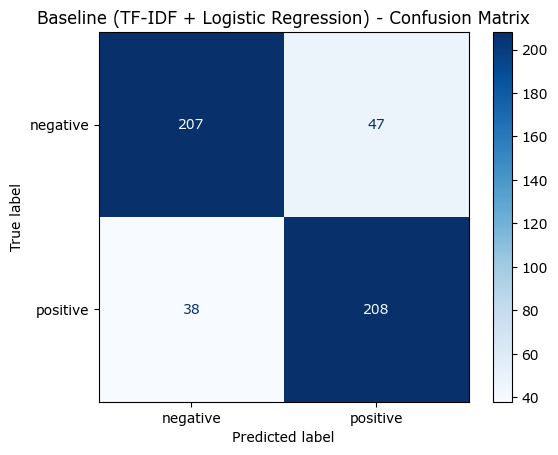

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_test, baseline_preds, target_names=["negative", "positive"]))

cm = confusion_matrix(y_test, baseline_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "positive"])
disp.plot(cmap="Blues")
plt.title("Baseline (TF-IDF + Logistic Regression) - Confusion Matrix")
plt.show()

## Step 6 — Fine-tuning: tokenize the data for DistilBERT

DistilBERT needs text broken into its own vocabulary of sub-word pieces (not TF-IDF's word counts), plus padding/truncation so every review becomes a fixed-size input.

In [7]:
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    # truncation=True cuts reviews longer than max_length; padding makes short ones the same length
    # max_length=128 (not 256+) is a deliberate speed tradeoff: we're training on CPU, and this
    # roughly halves compute. It truncates some longer reviews, which is a real accuracy cost we're
    # accepting to keep iteration fast while learning the pipeline.
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

train_tokenized = train_small.map(tokenize, batched=True)
test_tokenized = test_small.map(tokenize, batched=True)

# Trainer expects a column named "labels" (not "label")
train_tokenized = train_tokenized.rename_column("label", "labels")
test_tokenized = test_tokenized.rename_column("label", "labels")

# Keep only the columns the model needs, as PyTorch tensors
columns = ["input_ids", "attention_mask", "labels"]
train_tokenized.set_format(type="torch", columns=columns)
test_tokenized.set_format(type="torch", columns=columns)

train_tokenized[0]["input_ids"][:20]

tensor([ 101, 2045, 2003, 2053, 7189, 2012, 2035, 2090, 3481, 3771, 1998, 6337,
        2099, 2021, 1996, 2755, 2008, 2119, 2024, 2610])

## Step 7 — Load DistilBERT and configure fine-tuning

We load a pretrained DistilBERT with a fresh classification head on top (2 classes), then define how training should run (learning rate, batch size, epochs) and how to compute metrics during training.

In [8]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# num_labels=2 attaches a fresh (untrained) 2-class classification head on top of pretrained DistilBERT
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)  # pick the class with the highest score
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",       # evaluate on test set after each epoch
    save_strategy="no",          # don't checkpoint to disk, we're experimenting
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,          # small LR: we're gently nudging pretrained weights, not starting from scratch
    logging_steps=25,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics,
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Step 8 — Fine-tune

This is the actual training loop: the Trainer feeds batches through DistilBERT, computes the loss, and updates the weights. On CPU this takes a while — it evaluates on the test set after each epoch so we can watch progress.

In [9]:
train_result = trainer.train()
train_result

C:\Users\reema\AppData\Roaming\Python\Python312\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.376700,0.427385,0.798000,0.739274,0.910569,0.816029
2,0.303300,0.420816,0.818000,0.796935,0.845528,0.820513


C:\Users\reema\AppData\Roaming\Python\Python312\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=250, training_loss=0.4116040267944336, metrics={'train_runtime': 1387.2374, 'train_samples_per_second': 2.883, 'train_steps_per_second': 0.18, 'total_flos': 132467398656000.0, 'train_loss': 0.4116040267944336, 'epoch': 2.0})

## Step 9 — Evaluate DistilBERT the same way as the baseline

Same metrics, same test set, so the comparison is fair: precision/recall/F1 and a confusion matrix.

C:\Users\reema\AppData\Roaming\Python\Python312\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


              precision    recall  f1-score   support

    negative       0.84      0.79      0.82       254
    positive       0.80      0.85      0.82       246

    accuracy                           0.82       500
   macro avg       0.82      0.82      0.82       500
weighted avg       0.82      0.82      0.82       500



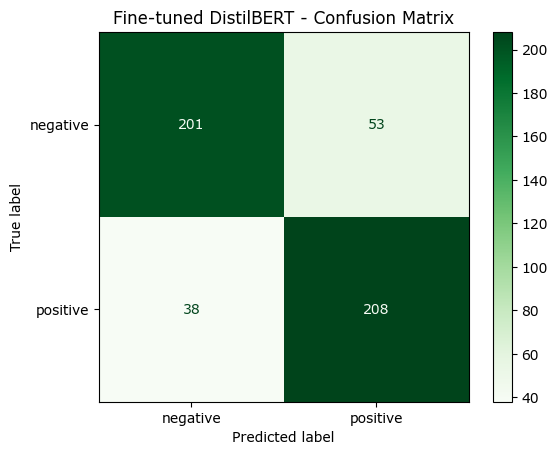

In [10]:
predictions = trainer.predict(test_tokenized)
distilbert_preds = np.argmax(predictions.predictions, axis=1)

print(classification_report(y_test, distilbert_preds, target_names=["negative", "positive"]))

cm_bert = confusion_matrix(y_test, distilbert_preds)
disp_bert = ConfusionMatrixDisplay(confusion_matrix=cm_bert, display_labels=["negative", "positive"])
disp_bert.plot(cmap="Greens")
plt.title("Fine-tuned DistilBERT - Confusion Matrix")
plt.show()

## Step 10 — Compare baseline vs DistilBERT

A single table, same metrics, side by side.

In [11]:
def summarize(name, y_true, preds):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, preds, average="binary")
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

comparison = pd.DataFrame([
    summarize("TF-IDF + Logistic Regression", y_test, baseline_preds),
    summarize("Fine-tuned DistilBERT", y_test, distilbert_preds),
])
comparison

,model,accuracy,precision,recall,f1
0,TF-IDF + Logistic Regression,0.830,0.815686,0.845528,0.830339
1,Fine-tuned DistilBERT,0.818,0.796935,0.845528,0.820513


## Step 11 — Where do they actually disagree?

Overall metrics hide the interesting part. Let's look at specific reviews where one model got it right and the other got it wrong — this tells us *what kind of* language trips up the simpler model.

In [12]:
results_df = pd.DataFrame({
    "text": test_small["text"],
    "true_label": y_test,
    "baseline_pred": baseline_preds,
    "distilbert_pred": distilbert_preds,
})

baseline_wrong_bert_right = results_df[
    (results_df["baseline_pred"] != results_df["true_label"]) &
    (results_df["distilbert_pred"] == results_df["true_label"])
]
bert_wrong_baseline_right = results_df[
    (results_df["distilbert_pred"] != results_df["true_label"]) &
    (results_df["baseline_pred"] == results_df["true_label"])
]

print(f"Baseline wrong, DistilBERT right: {len(baseline_wrong_bert_right)} examples")
print(f"DistilBERT wrong, baseline right: {len(bert_wrong_baseline_right)} examples")

Baseline wrong, DistilBERT right: 50 examples
DistilBERT wrong, baseline right: 56 examples


In [13]:
def show_examples(df, n=3):
    for _, row in df.head(n).iterrows():
        label = "positive" if row["true_label"] == 1 else "negative"
        print(f"[true label: {label}]")
        print(row["text"][:400], "...\n")

print("=== Baseline WRONG, DistilBERT RIGHT ===\n")
show_examples(baseline_wrong_bert_right)

print("\n=== DistilBERT WRONG, baseline RIGHT ===\n")
show_examples(bert_wrong_baseline_right)

=== Baseline WRONG, DistilBERT RIGHT ===

[true label: negative]
Not much to say other than plenty of Wire-fu and supposed Sholin monks ego-tripping about Kung-fu and caricature Japanese plotting to take over China. All of this would not be so bad if not for the utterly fake Japanese sword fighting. If you watched a Samurai movie or two you can tell that the "Japanese" fighting in the movie is simply the same "Kung-fu" (Really circus acrobats) stunt men doing t ...

[true label: positive]
It's really too bad that nobody knows about this movie. I think if it were just spruced up a little and if it weren't so low-budget, I think one of the major film companies might have wanted to take it. I first saw this movie when I was 11, and I thought it was so powerful with the many great, yet illegal lengths that Mitchell goes to just to keep his family together. It inspired me then and it am ...

[true label: negative]
A very sensitive topic--15 y/o girl abandoned by mother as a baby and who goe